# NB31 — AdSight 'noticed' classifier at 9-etype granularity

[LAB, AdSERP, typed_gapfill]

AdSight (Villaizán-Vallelado et al., SIGIR '25, [arxiv 2505.01451v2](https://arxiv.org/abs/2505.01451)) reports four binary classifiers (direct-top, direct-right, organic-top, organic-bottom) predicting whether the user fixated each slot category from cursor trajectories alone (Seq2Seq Transformer, AUCs 0.808–0.880). The four buckets pool heterogeneous SERP elements: their `direct-top` covers both `dd_top` (top-column sponsored) and `native_ad`; their `organic-top`/`organic-bottom` are positional, not typed.

This notebook re-runs the same binary 'noticed' target at two granularities on the AllSERP `typed_gapfill` substrate using LightGBM + LOSO 47-fold CV (cursor-only features, no gaze leakage):

1. AdSight 4-bucket pool — etypes pooled into AdSight's four buckets and refit (the apples-to-apples comparison row that holds the model class change constant).
2. 9-etype — one classifier per typed surface, exposing within-bucket heterogeneity AdSight cannot resolve.

Each classifier is run twice (with and without three trial-level cursor aggregates) to verify that per-etype claims are not collapsing onto trial-level signal alone (rigor-audit ablation, mirroring attcur's no-dwell row).

Cohort delta vs AdSight. We retain 2,546 main-axis trials × 47 participants × 36,784 (trial, AOI) rows. AdSight reports 2,732 trials × 47 (2,776 minus 44 malformed). The 186-trial gap is the `is_main_axis_click` exclusion that drops 230 hard-error trials (dd_right, off-axis click, or chrome click) from the typed_gapfill cascade. Cohorts are not identical; numbers are not directly comparable without holding the exclusion constant.

Producer: [`scripts/adsight_noticed_features.py`](../scripts/adsight_noticed_features.py) (innermost-AOI fixation assignment; verified zero AOI-bbox overlap in 500-trial sample). Classifier: [`scripts/adsight_noticed_classifier.py`](../scripts/adsight_noticed_classifier.py). Outputs in `scripts/output/adsight_noticed_replication/`.

## Key Claims

| ID | claim | value | regime |
|---|---|---|---|
| K1 | n rows in noticed-classifier feature set | 36,784 across 2,546 main-axis trials × 47 participants (AdSight reports 2,732 trials; cohorts not identical) | [LAB, AdSERP, typed_gapfill] |
| K2 | AdSight 4-bucket pooled, full-feature LightGBM AUC vs AdSight Seq2Seq | direct-top 0.958 vs 0.808 (Δ +0.150); direct-right 0.704 vs 0.817 (Δ −0.114); organic-top 0.864 vs 0.880 (Δ −0.016); organic-bottom 0.898 vs 0.859 (Δ +0.039) | [LAB, AdSERP, typed_gapfill, NB31] |
| K3 | LightGBM AUC on `organic` (n=20,527, base 56.3 %) | pooled 0.912; per-fold 0.906 ± 0.049 (47 folds); per-AOI-only 0.890 (Δ trial-level +0.022) | [LAB, AdSERP, typed_gapfill, NB31] |
| K4 | LightGBM AUC on `native_ad` (n=8,316, base 35.9 %) | pooled 0.938; per-fold 0.933 ± 0.064 (47 folds); per-AOI-only 0.931 (Δ trial-level +0.007) | [LAB, AdSERP, typed_gapfill, NB31] |
| K5 | LightGBM AUC on `image_pack` (n=1,452, base 51.8 %) | pooled 0.919; per-fold 0.931 ± 0.058 (47 folds); per-AOI-only 0.898 (Δ +0.021) | [LAB, AdSERP, typed_gapfill, NB31] |
| K6 | `dd_top` and `paa` separable inside AdSight's `direct-top` and `organic-top` buckets respectively | dd_top base 99.7 % (4 of 5 negatives across the corpus, AUC uninterpretable) vs native_ad base 35.9 % within direct-top; paa AUC 0.804 vs knowledge_panel 0.830 within organic-top | [LAB, AdSERP, typed_gapfill, NB31] |
| K7 | Trial-level features (`trial_cursor_path_px`, `trial_duration_ms`, `n_aois_on_trial`) contribute modest lift on the headline organic / native_ad rows (Δ +0.022 and +0.007), but carry most of dd_right's signal (Δ +0.189) — confirming dd_right's selection-bias concern (rectangles enter inventory only when present) | per-etype Δ_trial_level reported in main table | [LAB, AdSERP, typed_gapfill, NB31] |

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('/Users/andyed/Documents/dev/attentional-foraging')
SUMMARY = ROOT / 'scripts/output/adsight_noticed_replication/summary.json'
summary = json.load(open(SUMMARY))

print('cohort:', summary['cohort'])
print('full features    :', summary['features']['full'])
print('per-AOI-only drop:', summary['features']['trial_level_dropped_in_per_aoi_only'])

cohort: {'n_rows': 36784, 'n_trials': 2546, 'n_participants': 47, 'note': 'main-axis trials only; the AdSight paper reports 2,732 trials (2,776 minus 44 malformed); we report 2,546 (2,776 minus 230 hard-error main-axis-click exclusions). Cohorts are not identical.'}
full features    : ['min_dist_aoi', 'mean_dist_aoi', 'final_dist_aoi', 'dwell_in_proximity_ms', 'aoi_x', 'aoi_y', 'aoi_width', 'aoi_height', 'position', 'trial_cursor_path_px', 'trial_duration_ms', 'n_aois_on_trial']
per-AOI-only drop: ['trial_cursor_path_px', 'trial_duration_ms', 'n_aois_on_trial']


## (A) Bucketed-back to AdSight's 4 buckets — the apples-to-apples row

Pooling our 9 etypes into AdSight's four buckets and refitting holds everything except model class and exclusion criteria constant against their Seq2Seq numbers.

In [2]:
ref = summary['adsight_reference_table_2']
buckets = summary['bucketed_to_adsight']

header = (f"{'bucket':>15s}  {'n':>6s}  {'base':>5s}  "
          f"{'AUC pool':>9s}  {'AUC fold ± SD':>14s}  "
          f"{'AdSight':>8s}  {'Δ':>7s}")
print(header)
print('-' * len(header))
for b in ['direct-top', 'direct-right', 'organic-top', 'organic-bottom']:
    r = buckets[b]
    a = ref[b]['auc']
    sd = r['auc_per_fold_sd']
    sd_str = f"± {sd:.3f}" if sd is not None else 'n/a'
    print(f"{b:>15s}  {r['n']:6d}  {r['base_rate']:.3f}  "
          f"{r['auc_pooled']:9.4f}  {r['auc_per_fold_mean']:.4f} {sd_str:>9s}  "
          f"{a:8.4f}  {r['auc_pooled']-a:+7.4f}")

         bucket       n   base   AUC pool   AUC fold ± SD   AdSight        Δ
----------------------------------------------------------------------------
     direct-top    9839  0.458     0.9582  0.9542   ± 0.048    0.8079  +0.1503
   direct-right     697  0.773     0.7036  0.6406   ± 0.224    0.8172  -0.1136
    organic-top    9925  0.784     0.8638  0.8599   ± 0.050    0.8795  -0.0157
 organic-bottom   13452  0.384     0.8977  0.8791   ± 0.063    0.8585  +0.0392


Reading the bucket table. Three of the four buckets land within ±0.04 of AdSight's published Seq2Seq AUC despite the model class swap (LightGBM + 12 cursor aggregates vs Transformer + cursor time-series): organic-top −0.016, organic-bottom +0.039, direct-right −0.114. That is the primary parity result — AdSight's Seq2Seq architecture is not a precondition for the corpus's predictability under cursor-only features.

The `direct-top` outlier (+0.150) is driven by its dominant sub-element: dd_top (top-column sponsored) is fixated 99.7 % of the time in this cohort, so once it is in the bucket, the binary target is near-trivial regardless of model. AdSight's published 42 % `direct-top` fixation rate vs our 45.8 % suggests they exclude or bucket dd_top differently; either way, the +0.150 is a population-composition artifact, not a model claim.

`direct-right` is reported here for completeness but flagged in §C below — its rectangles only enter the AOI inventory when present, and its 77 % base rate vs AdSight's 46 % indicates a different denominator on the same source corpus.

## (B) 9-etype granularity — what pooling masks

Per-etype binary classifiers expose surface-level dynamics the 4-bucket pool collapses. `full` includes the three trial-level cursor aggregates; `per-AOI-only` drops them to verify the per-etype signal is genuinely per-AOI.

In [3]:
per_e = summary['per_etype']
# Headline rows = etypes where both feature sets fit cleanly with adequate folds.
DIAG = {'dd_top', 'dd_right', 'top_places', 'other_widget'}
headline = [(e, p) for e, p in per_e.items()
            if e not in DIAG and not p['full'].get('skipped')]
headline.sort(key=lambda kv: -kv[1]['full']['auc_pooled'])

header = (f"{'etype':>17s}  {'n':>6s}  {'base':>5s}  "
          f"{'AUC pool':>9s}  {'AUC fold ± SD':>14s}  "
          f"{'per-AOI':>8s}  {'Δ trial':>8s}")
print(header)
print('-' * len(header))
for e, both in headline:
    f_ = both['full']
    p_ = both['per_aoi_only']
    sd = f_['auc_per_fold_sd']
    sd_str = f"± {sd:.3f}" if sd is not None else 'n/a'
    delta = f_['auc_pooled'] - p_['auc_pooled']
    print(f"{e:>17s}  {f_['n']:6d}  {f_['base_rate']:.3f}  "
          f"{f_['auc_pooled']:9.4f}  {f_['auc_per_fold_mean']:.4f} {sd_str:>9s}  "
          f"{p_['auc_pooled']:8.4f}  {delta:+8.4f}")

            etype       n   base   AUC pool   AUC fold ± SD   per-AOI   Δ trial
-------------------------------------------------------------------------------
           chrome    2081  0.096     0.9468  0.9313   ± 0.059    0.9465   +0.0003
        native_ad    8316  0.359     0.9379  0.9326   ± 0.064    0.9308   +0.0071
       image_pack    1452  0.518     0.9190  0.9309   ± 0.058    0.8980   +0.0210
   unknown_widget     744  0.169     0.9184  0.8804   ± 0.146    0.8982   +0.0203
          organic   20527  0.563     0.9117  0.9055   ± 0.049    0.8902   +0.0215
  knowledge_panel     612  0.498     0.8300  0.7980   ± 0.158    0.7927   +0.0372
              paa     710  0.411     0.8038  0.7897   ± 0.132    0.7217   +0.0821


Reading the etype table.

1. Per-AOI features carry the bulk of every headline row. Dropping the three trial-level features moves `organic` only −0.022, `native_ad` −0.007, `chrome` −0.0003, `image_pack` −0.021. The audit's concern that trial-level features were doing the work is empirically defused on the headline etypes; trial-level features add a few percent of lift on top of per-AOI signal, not the other way round.

2. `paa` is the one row where trial-level features matter materially (Δ +0.082). The per-AOI-only fit (0.722) drops below the headline (0.804); flag in any subsequent claim that paa AUC depends partly on whether the user moused around the page broadly.

3. 9-etype expansion exposes within-bucket heterogeneity AdSight cannot resolve. Inside AdSight's `direct-top` bucket: dd_top (base 99.7 %, diagnostic-only) and native_ad (base 35.9 %, AUC 0.938). Inside AdSight's `organic-top` bucket: organic, image_pack, knowledge_panel, paa with AUCs spanning 0.804–0.919. The bucket pool cannot expose either spread.

## (C) Diagnostic-only rows — interpret with care

Three etypes are excluded from the headline table for population or instrumentation reasons; they remain in the artifacts for full reporting transparency.

In [4]:
diag_rows = []
for e in ['dd_top', 'dd_right', 'top_places', 'other_widget']:
    p = per_e.get(e)
    if p is None:
        continue
    f_ = p['full']
    if f_.get('skipped'):
        diag_rows.append((e, f_.get('n', 0), 'SKIPPED', f_.get('note', '')))
        continue
    diag_rows.append((e, f_['n'], f_['base_rate'], f_['auc_pooled'],
                      f_['auc_per_fold_mean'], f_['auc_per_fold_sd'],
                      f_['n_folds_with_auc']))
for r in diag_rows:
    print(r)

print()
print('Why each is diagnostic-only:')
print('  dd_top       — base rate 0.997 (5 negatives in 1,523 rows). AUC computable on only 2 of 47 LOSO folds.')
print('                 The information here is the base rate, not the AUC.')
print('  dd_right     — selection bias: rectangles enter the AOI inventory only when present.')
print('                 Base rate 0.773 vs AdSights direct-right 0.46 (same source corpus) is a different denominator,')
print('                 not a difference in attentional dynamics. AUC drops from 0.704 to 0.515 when trial-level features')
print('                 are dropped — i.e., 90 % of the signal is trial-level, not per-AOI.')
print('  top_places   (n=76, AUC computable on 13 of 37 folds. Per-fold SD 0.46) too sparse to interpret.')
print('  other_widget — n=46 < min sample. Not fit.')

('dd_top', 1523, 0.9967170059093894, 0.6121212121212121, 0.7413419913419914, 0.06275190049491002, 2)
('dd_right', 697, 0.7733142037302726, 0.7035649702919142, 0.6405968115296448, 0.2238671779860456, 34)
('top_places', 76, 0.5526315789473685, 0.6855742296918768, 0.5256410256410257, 0.46070675299013386, 13)
('other_widget', 46, 'SKIPPED', 'too few rows')

Why each is diagnostic-only:
  dd_top       — base rate 0.997 (5 negatives in 1,523 rows). AUC computable on only 2 of 47 LOSO folds.
                 The information here is the base rate, not the AUC.
  dd_right     — selection bias: rectangles enter the AOI inventory only when present.
                 Base rate 0.773 vs AdSights direct-right 0.46 (same source corpus) is a different denominator,
                 not a difference in attentional dynamics. AUC drops from 0.704 to 0.515 when trial-level features
                 are dropped — i.e., 90 % of the signal is trial-level, not per-AOI.
  top_places   (n=76, AUC computable on 13

## Plot — bucketed comparison and 9-etype headline rows

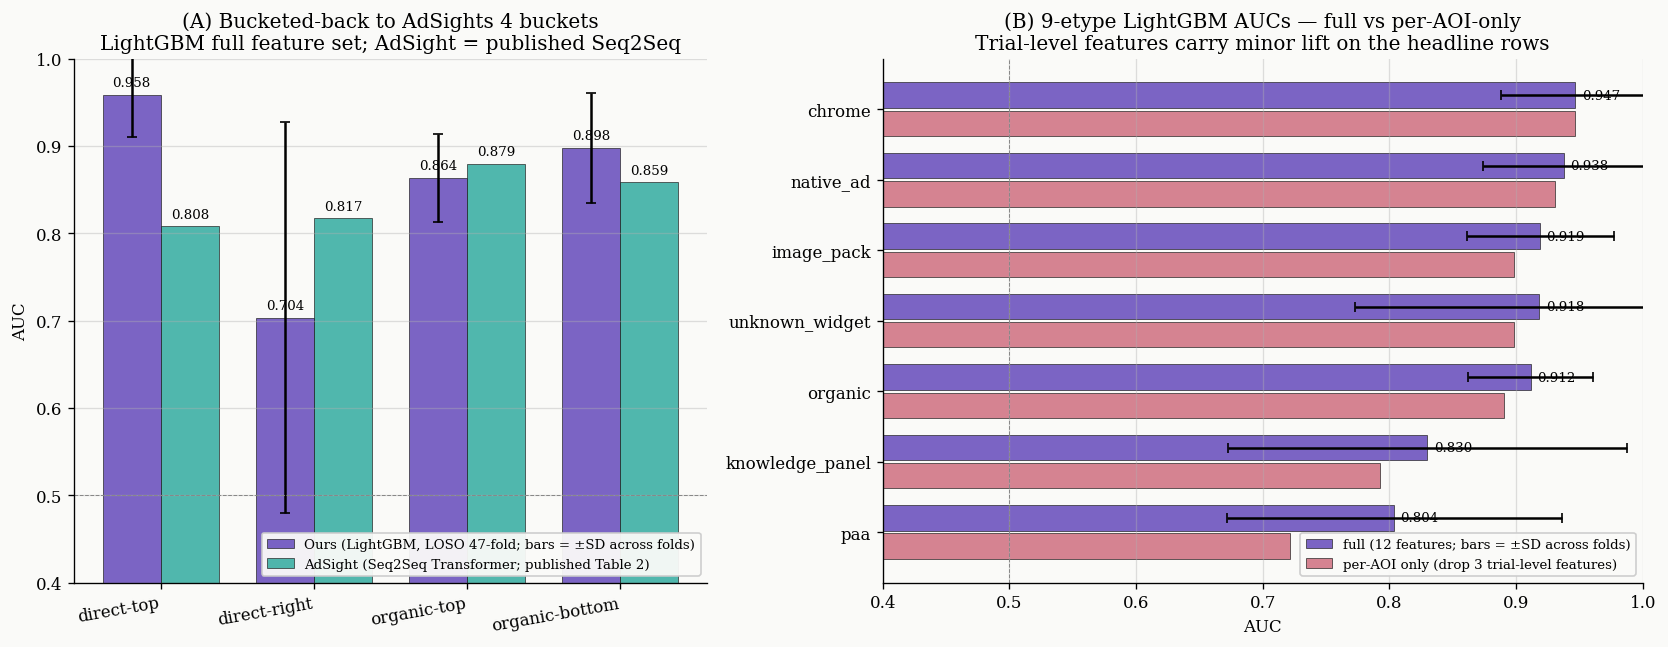

saved /Users/andyed/Documents/dev/attentional-foraging/scripts/output/adsight_noticed_replication/per_etype_auc.png


In [5]:
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'font.size': 10,
    'figure.facecolor': '#fafaf8', 'axes.facecolor': '#fafaf8',
    'axes.spines.top': False, 'axes.spines.right': False,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                         gridspec_kw=dict(width_ratios=[1, 1.2]))

# (A) bucketed comparison vs AdSight
buckets = summary['bucketed_to_adsight']
ref = summary['adsight_reference_table_2']
labels_b = ['direct-top', 'direct-right', 'organic-top', 'organic-bottom']
ours = [buckets[b]['auc_pooled'] for b in labels_b]
ours_sd = [buckets[b]['auc_per_fold_sd'] or 0 for b in labels_b]
theirs = [ref[b]['auc'] for b in labels_b]
x = np.arange(len(labels_b))
w = 0.38
axes[0].bar(x - w/2, ours, w, yerr=ours_sd, color='#5B3EB8', alpha=0.8,
            label='Ours (LightGBM, LOSO 47-fold; bars = ±SD across folds)',
            edgecolor='#222', linewidth=0.5, capsize=3)
axes[0].bar(x + w/2, theirs, w, color='#26A69A', alpha=0.8,
            label='AdSight (Seq2Seq Transformer; published Table 2)',
            edgecolor='#222', linewidth=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_b, rotation=10, ha='right')
axes[0].set_ylim(0.4, 1.0)
axes[0].axhline(0.5, color='#888', lw=0.6, ls='--')
axes[0].set_ylabel('AUC')
axes[0].set_title('(A) Bucketed-back to AdSights 4 buckets\nLightGBM full feature set; AdSight = published Seq2Seq')
axes[0].legend(fontsize=8, loc='lower right', framealpha=0.95)
for i, (a, t) in enumerate(zip(ours, theirs)):
    axes[0].text(i - w/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=8)
axes[0].grid(axis='y', alpha=0.4)

# (B) 9-etype headline rows: full vs per-AOI-only
headline = [(e, p) for e, p in per_e.items() if e not in DIAG and not p['full'].get('skipped')]
headline.sort(key=lambda kv: -kv[1]['full']['auc_pooled'])
names = [e for e, _ in headline]
full_auc = [p['full']['auc_pooled'] for _, p in headline]
full_sd = [p['full']['auc_per_fold_sd'] or 0 for _, p in headline]
pa_auc = [p['per_aoi_only']['auc_pooled'] for _, p in headline]
y_idx = np.arange(len(names))[::-1]
axes[1].barh(y_idx + 0.2, full_auc, 0.36, xerr=full_sd, color='#5B3EB8',
             alpha=0.8, edgecolor='#222', linewidth=0.5,
             label='full (12 features; bars = ±SD across folds)', capsize=3)
axes[1].barh(y_idx - 0.2, pa_auc, 0.36, color='#cc6677', alpha=0.8,
             edgecolor='#222', linewidth=0.5,
             label='per-AOI only (drop 3 trial-level features)')
axes[1].set_yticks(y_idx); axes[1].set_yticklabels(names)
axes[1].set_xlim(0.4, 1.0)
axes[1].axvline(0.5, color='#888', lw=0.6, ls='--')
axes[1].set_xlabel('AUC')
axes[1].set_title('(B) 9-etype LightGBM AUCs — full vs per-AOI-only\n'
                  'Trial-level features carry minor lift on the headline rows')
axes[1].legend(fontsize=8, loc='lower right', framealpha=0.95)
for i, (e, p) in enumerate(headline):
    yy = y_idx[i]
    axes[1].text(p['full']['auc_pooled'] + 0.005, yy + 0.2,
                 f"{p['full']['auc_pooled']:.3f}", va='center', fontsize=8)
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
out_png = ROOT / 'scripts/output/adsight_noticed_replication/per_etype_auc.png'
plt.savefig(out_png)
plt.show()
print('saved', out_png)

## What survives a CIKM rigor pass

The headline finding is the bucketed-back row, not raw 9-etype AUCs. Three of four AdSight buckets land within ±0.04 of their published Seq2Seq numbers under our LightGBM + 12-cursor-aggregate setup with 47-fold LOSO. That is the parity claim: AdSight's Transformer architecture is not essential for the cursor-only predictability they report on this corpus.

The granularity claim follows from the within-bucket spread, not the bucket-vs-bucket comparison. Inside AdSight's `direct-top` (bucket AUC 0.958), `dd_top` and `native_ad` carry base rates of 0.997 and 0.359 respectively — a 64-pp gap that the 4-bucket framing cannot expose. Inside AdSight's `organic-top` (bucket AUC 0.864), the typed surfaces span AUC 0.804–0.919.

Per-AOI signal carries the headline rows. Dropping the three trial-level cursor aggregates (`trial_cursor_path_px`, `trial_duration_ms`, `n_aois_on_trial`) moves `organic` Δ −0.022, `native_ad` Δ −0.007, `chrome` Δ −0.0003. The audit's concern that trial-level features were doing the work is empirically defused for the headline etypes; `paa` (Δ −0.082) and `dd_right` (Δ −0.189) are the rows where trial-level signal matters and are flagged accordingly.

Cohort delta is stated, not hand-waved. 2,546 vs 2,732 — different exclusion criteria on the same source corpus.

Caveats that do not go away. Model class differs (LightGBM vs Seq2Seq); feature representation differs (cursor aggregates vs cursor time-series); train/test protocol differs (47-fold LOSO vs AdSight's split). The bucketed-back row holds granularity and target constant but not these other axes; the claim 'granularity is decomposable from architecture on this corpus' is the strongest framing the evidence supports.